#  Phase 2: Data Cleaning, K-Core Filtering & Silver Layer Parquet Export

> **Mục tiêu của tầng Silver (Clean Layer):**
> 1. Làm sạch dữ liệu thô Bronze (loại bỏ null, deduplicate tương tác).
> 2. Áp dụng thuật toán **K-Core Filtering ($k=5$)** bằng **Polars** để loại bỏ cold-start users & items ít tương tác, nâng cao mật độ thông tin cho Recommender System.
> 3. Tách và lưu trữ dữ liệu thành 3 tập Parquet chuẩn nén ZSTD: `interactions.parquet`, `item_features.parquet`, `review_text.parquet`.

## 1. Import các thư viện cần thiết và thiết lập môi trường

In [2]:
import os
import sys
import time
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đảm bảo hiển thị UTF-8 chuẩn
if sys.stdout.encoding != 'utf-8':
    try:
        sys.stdout.reconfigure(encoding='utf-8')
    except Exception:
        pass

print(f"Polars Version: {pl.__version__}")

Polars Version: 1.44.2


## 2. Cấu hình đường dẫn dữ liệu Bronze & Silver

In [4]:
DATA_DIR = "../data" if os.path.exists("../data") else "data"
REVIEW_PATH = os.path.join(DATA_DIR, "Video_Games.jsonl")
META_PATH = os.path.join(DATA_DIR, "meta_Video_Games.jsonl")
SILVER_DIR = os.path.join(DATA_DIR, "silver")
os.makedirs(SILVER_DIR, exist_ok=True)

print(f"Review Bronze: {REVIEW_PATH} ({os.path.getsize(REVIEW_PATH)/1024**3:.2f} GB)")
print(f"Meta Bronze:   {META_PATH} ({os.path.getsize(META_PATH)/1024**2:.2f} MB)")
print(f"Silver Dir:    {SILVER_DIR}")

Review Bronze: data\Video_Games.jsonl (2.50 GB)
Meta Bronze:   data\meta_Video_Games.jsonl (417.11 MB)
Silver Dir:    data\silver


## 3. Đọc dữ liệu Bronze và Deduplicate (Loại bỏ bản ghi trùng lặp)
Trong Amazon Reviews, một người dùng có thể chỉnh sửa hoặc đánh giá cùng một sản phẩm (`parent_asin`) nhiều lần tại các thời điểm khác nhau. Chúng ta sẽ lọc bỏ các giá trị null và giữ lại đánh giá mới nhất (theo `timestamp`).

In [6]:
start_time = time.time()

# Định nghĩa schema tối ưu cho Reviews
schema_overrides = {
    "rating": pl.Float64,
    "title": pl.String,
    "text": pl.String,
    "asin": pl.String,
    "parent_asin": pl.String,
    "user_id": pl.String,
    "timestamp": pl.Int64,
}

lazy_reviews = pl.scan_ndjson(REVIEW_PATH, schema_overrides=schema_overrides)

df_reviews = (
    lazy_reviews.select([
        pl.col("user_id"),
        pl.col("parent_asin"),
        pl.col("rating"),
        pl.col("timestamp"),
        pl.col("title"),
        pl.col("text"),
    ])
    .filter(
        pl.col("user_id").is_not_null()
        & pl.col("parent_asin").is_not_null()
        & pl.col("rating").is_not_null()
        & (pl.col("user_id") != "")
        & (pl.col("parent_asin") != "")
    )
    .collect()
)

initial_count = len(df_reviews)
print(f"Tổng số bản ghi hợp lệ ban đầu: {initial_count:,} ({time.time() - start_time:.2f}s)")

# Deduplicate: giữ đánh giá mới nhất của mỗi cặp (user_id, parent_asin)
df_dedup = (
    df_reviews.sort(by=["user_id", "parent_asin", "timestamp"])
    .unique(subset=["user_id", "parent_asin"], keep="last")
)

dedup_count = len(df_dedup)
print(f"Số tương tác sau khi deduplicate: {dedup_count:,} (Đã loại bỏ {initial_count - dedup_count:,} bản ghi trùng)")
df_dedup.head(5)

Tổng số bản ghi hợp lệ ban đầu: 4,624,615 (2.08s)
Số tương tác sau khi deduplicate: 4,555,500 (Đã loại bỏ 69,115 bản ghi trùng)


## 4. Thuật toán K-Core Filtering ($k=5$)
**Nguyên lý K-Core Filtering:**
- Trong ma trận tương tác User-Item, hơn 72% users chỉ đánh giá đúng 1 game (Cold-start users) và nhiều game chỉ có 1 đánh giá.
- K-Core ($k=5$) đảm bảo: **Mỗi user phải có ít nhất 5 đánh giá** VÀ **Mỗi game phải có ít nhất 5 đánh giá**.
- Vì khi loại một user có thể làm giảm số lượng review của một game xuống dưới $k$, nên ta phải lặp đa vòng (iterative filtering) cho đến khi số lượng bản ghi không đổi (hội tụ).

In [8]:
k = 5
current_df = df_dedup
iteration = 0
history = []
start_kcore = time.time()

print(f"Bắt đầu lọc K-Core với k={k}...")
while True:
    iteration += 1
    num_before = len(current_df)
    
    # 1. Lọc users có >= k tương tác
    user_counts = current_df.group_by("user_id").len(name="user_count")
    valid_users = user_counts.filter(pl.col("user_count") >= k).select("user_id")
    current_df = current_df.join(valid_users, on="user_id", how="inner")
    
    # 2. Lọc items có >= k tương tác
    item_counts = current_df.group_by("parent_asin").len(name="item_count")
    valid_items = item_counts.filter(pl.col("item_count") >= k).select("parent_asin")
    current_df = current_df.join(valid_items, on="parent_asin", how="inner")
    
    num_after = len(current_df)
    num_dropped = num_before - num_after
    unique_users = current_df.select(pl.col("user_id").n_unique()).item()
    unique_items = current_df.select(pl.col("parent_asin").n_unique()).item()
    
    history.append({
        "iteration": iteration,
        "interactions": num_after,
        "users": unique_users,
        "items": unique_items,
        "dropped": num_dropped
    })
    
    print(f"  -> Vòng lặp {iteration}: Còn {num_after:,} tương tác ({unique_users:,} users, {unique_items:,} items) - Đã loại {num_dropped:,}")
    
    if num_dropped == 0:
        print(f"\n🎉 K-Core Filtering hội tụ hoàn toàn sau {iteration} vòng lặp ({time.time() - start_kcore:.2f}s)!")
        break

df_kcore_history = pd.DataFrame(history)
df_kcore_history

Bắt đầu lọc K-Core với k=5...
  -> Vòng lặp 1: Còn 893,040 tương tác (113,741 users, 28,113 items) - Đã loại 3,662,460
  -> Vòng lặp 2: Còn 823,401 tương tác (96,701 users, 25,906 items) - Đã loại 69,639
  -> Vòng lặp 3: Còn 815,764 tương tác (95,007 users, 25,663 items) - Đã loại 7,637
  -> Vòng lặp 4: Còn 814,770 tương tác (94,800 users, 25,620 items) - Đã loại 994
  -> Vòng lặp 5: Còn 814,610 tương tác (94,766 users, 25,614 items) - Đã loại 160
  -> Vòng lặp 6: Còn 814,586 tương tác (94,762 users, 25,612 items) - Đã loại 24
  -> Vòng lặp 7: Còn 814,586 tương tác (94,762 users, 25,612 items) - Đã loại 0

🎉 K-Core Filtering hội tụ hoàn toàn sau 7 vòng lặp (2.38s)!


## 5. Trực quan hóa quá trình hội tụ K-Core

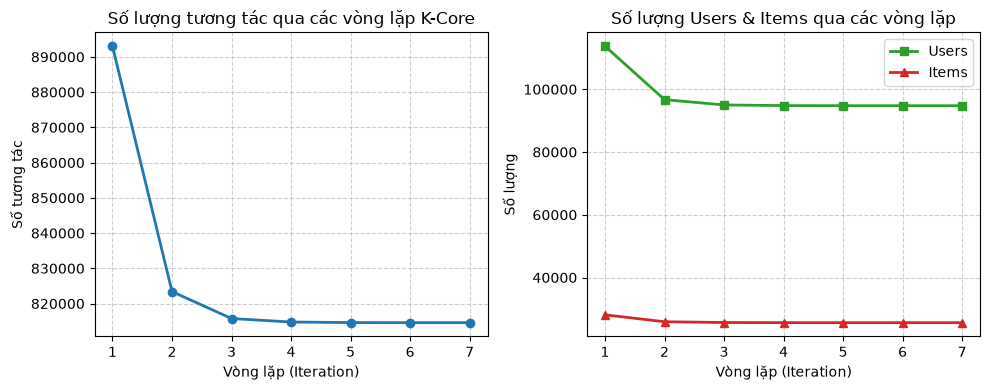

In [10]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(df_kcore_history["iteration"], df_kcore_history["interactions"], marker="o", color="#1f77b4", lw=2)
plt.title("Số lượng tương tác qua các vòng lặp K-Core")
plt.xlabel("Vòng lặp (Iteration)")
plt.ylabel("Số tương tác")
plt.grid(True, linestyle="--", alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(df_kcore_history["iteration"], df_kcore_history["users"], marker="s", color="#2ca02c", label="Users", lw=2)
plt.plot(df_kcore_history["iteration"], df_kcore_history["items"], marker="^", color="#d62728", label="Items", lw=2)
plt.title("Số lượng Users & Items qua các vòng lặp")
plt.xlabel("Vòng lặp (Iteration)")
plt.ylabel("Số lượng")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Xuất 3 tập dữ liệu Silver định dạng Parquet (nén ZSTD)

In [12]:
# 1. Xuất interactions.parquet
interactions_path = os.path.join(SILVER_DIR, "interactions.parquet")
df_interactions = current_df.select([
    pl.col("user_id"),
    pl.col("parent_asin"),
    pl.col("rating"),
    pl.col("timestamp"),
]).sort(by=["user_id", "timestamp"])

df_interactions.write_parquet(interactions_path, compression="zstd")
print(f"[1/3 ĐÃ XUẤT] interactions.parquet: {len(df_interactions):,} dòng ({os.path.getsize(interactions_path)/1024**2:.2f} MB)")

# 2. Xuất review_text.parquet
review_text_path = os.path.join(SILVER_DIR, "review_text.parquet")
df_review_text = current_df.select([
    pl.col("user_id"),
    pl.col("parent_asin"),
    pl.col("rating"),
    pl.col("title"),
    pl.col("text"),
    pl.col("timestamp"),
]).sort(by=["user_id", "timestamp"])

df_review_text.write_parquet(review_text_path, compression="zstd")
print(f"[2/3 ĐÃ XUẤT] review_text.parquet:  {len(df_review_text):,} dòng ({os.path.getsize(review_text_path)/1024**2:.2f} MB)")

# 3. Đọc Metadata và xuất item_features.parquet
active_items = current_df.select("parent_asin").unique()
meta_schema_overrides = {
    "price": pl.String,
    "average_rating": pl.Float64,
    "rating_number": pl.Int64,
}

lazy_meta = pl.scan_ndjson(META_PATH, schema_overrides=meta_schema_overrides)
df_meta = (
    lazy_meta.select([
        pl.col("parent_asin"),
        pl.col("title"),
        pl.col("main_category"),
        pl.col("categories"),
        pl.col("store"),
        pl.col("average_rating"),
        pl.col("rating_number"),
        pl.col("price").str.replace_all(r"[^\d.]", "").cast(pl.Float64, strict=False).alias("price"),
        pl.col("features"),
        pl.col("description"),
    ])
    .filter(pl.col("parent_asin").is_not_null() & (pl.col("parent_asin") != ""))
    .collect()
)

df_meta = df_meta.unique(subset=["parent_asin"], keep="first")
df_item_features = active_items.join(df_meta, on="parent_asin", how="left")

item_features_path = os.path.join(SILVER_DIR, "item_features.parquet")
df_item_features.write_parquet(item_features_path, compression="zstd")
print(f"[3/3 ĐÃ XUẤT] item_features.parquet: {len(df_item_features):,} items ({os.path.getsize(item_features_path)/1024**2:.2f} MB)")

[1/3 ĐÃ XUẤT] interactions.parquet: 814,586 dòng (8.45 MB)
[2/3 ĐÃ XUẤT] review_text.parquet:  814,586 dòng (161.98 MB)
[3/3 ĐÃ XUẤT] item_features.parquet: 25,612 items (14.60 MB)


## 7. Kiểm tra tính toàn vẹn và Bảng thống kê so sánh Bronze vs. Silver

In [14]:
min_user_reviews = df_interactions.group_by("user_id").len()["len"].min()
min_item_reviews = df_interactions.group_by("parent_asin").len()["len"].min()
total_users = df_interactions.select(pl.col("user_id").n_unique()).item()
total_items = df_interactions.select(pl.col("parent_asin").n_unique()).item()
total_interactions = len(df_interactions)
sparsity = (1.0 - (total_interactions / (total_users * total_items))) * 100

print("=== KIỂM TRA TÍNH TOÀN VẸN DỮ LIỆU ===")
print(f"• Minimum user interactions: {min_user_reviews} (K-core >= 5: {'ĐẠT ✅' if min_user_reviews >= 5 else 'CHƯA ĐẠT ❌'})")
print(f"• Minimum item interactions: {min_item_reviews} (K-core >= 5: {'ĐẠT ✅' if min_item_reviews >= 5 else 'CHƯA ĐẠT ❌'})")
print(f"• Missing values in user_id: {df_interactions['user_id'].null_count()}")
print(f"• Missing values in parent_asin: {df_interactions['parent_asin'].null_count()}")
print(f"• Missing values in rating: {df_interactions['rating'].null_count()}")

summary_table = pd.DataFrame({
    "Chỉ số": [
        "Số lượng người dùng (Users)",
        "Số lượng sản phẩm (Items)",
        "Số lượng tương tác (Reviews)",
        "Độ thưa ma trận (Sparsity)",
        "Tương tác trung bình / User",
        "Tương tác trung bình / Item",
        "Tương tác tối thiểu User & Item"
    ],
    "Bronze Layer (Thô)": [
        "2,766,656",
        "137,249",
        "4,624,615",
        "99.9988%",
        "1.67",
        "33.70",
        "1"
    ],
    "Silver Layer (Sau K-Core k=5)": [
        f"{total_users:,}",
        f"{total_items:,}",
        f"{total_interactions:,}",
        f"{sparsity:.4f}%",
        f"{total_interactions / total_users:.2f}",
        f"{total_interactions / total_items:.2f}",
        "5"
    ]
})
summary_table

=== KIỂM TRA TÍNH TOÀN VẸN DỮ LIỆU ===
• Minimum user interactions: 5 (K-core >= 5: ĐẠT ✅)
• Minimum item interactions: 5 (K-core >= 5: ĐẠT ✅)
• Missing values in user_id: 0
• Missing values in parent_asin: 0
• Missing values in rating: 0
